# Poisson Regression Model 

This notebook implements a Poisson regression model for predicting football match outcomes. The model is based on the assumption that goals in football matches follow Poisson distributions, which is a well-established approach in sports analytics.

## Mathematical Foundation

### Core Assumptions

The Poisson model makes several key assumptions:

1. **Independence**: Goals scored by each team are independent events
2. **Poisson Distribution**: The number of goals scored by each team follows a Poisson distribution
3. **Team Strength**: Each team has inherent attack and defense capabilities that remain constant within a season
4. **Home Advantage**: Playing at home provides a consistent advantage across all teams

### Model Formulation

For a match between home team $i$ and away team $j$, we model:

$$\text{Home goals} = X_h \sim \text{Poisson}(\lambda_{ij}^{home})$$
$$\text{Away goals} = X_a \sim \text{Poisson}(\lambda_{ij}^{away})$$

The expected number of goals (rate parameters) are modeled using log-linear relationships:

$$\log(\lambda_{ij}^{home}) = \alpha_i - \beta_j + \gamma$$
$$\log(\lambda_{ij}^{away}) = \alpha_j - \beta_i$$

Where:
- $\alpha_i$ = attack strength of team $i$
- $\beta_i$ = defense strength of team $i$ 
- $\gamma$ = home advantage parameter (shared across all teams)

### Identifiability Constraints

To ensure unique parameter estimates, we impose sum-to-zero constraints:

$$\sum_{i=1}^{n} \alpha_i = 0$$
$$\sum_{i=1}^{n} \beta_i = 0$$

These constraints prevent the model parameters from being arbitrarily shifted by a constant.

### Likelihood Function

The likelihood function for $n$ matches is:

$$L(\boldsymbol{\alpha}, \boldsymbol{\beta}, \gamma) = \prod_{k=1}^{n} P(x_k^{home} | \lambda_{k}^{home}) \cdot P(x_k^{away} | \lambda_{k}^{away})$$

Where $x_k^{home}$ and $x_k^{away}$ are the observed goals in match $k$.

For Poisson distributions:
$$P(x | \lambda) = \frac{\lambda^x e^{-\lambda}}{x!}$$

Taking the log-likelihood:
$$\log L = \sum_{k=1}^{n} \left[ x_k^{home} \log(\lambda_k^{home}) - \lambda_k^{home} + x_k^{away} \log(\lambda_k^{away}) - \lambda_k^{away} \right]$$

(We omit the $\log(x!)$ terms as they don't affect parameter optimization)

### Parameter Estimation

The model parameters $\boldsymbol{\theta} = (\boldsymbol{\alpha}, \boldsymbol{\beta}, \gamma)$ are estimated using **Maximum Likelihood Estimation (MLE)**:

1. **Objective Function**: Minimize the negative log-likelihood
   $$\min_{\boldsymbol{\theta}} -\log L(\boldsymbol{\theta})$$

2. **Constraints**: Enforce sum-to-zero constraints for identifiability
   $$\sum_{i=1}^{n} \alpha_i = 0, \quad \sum_{i=1}^{n} \beta_i = 0$$

3. **Bounds**: Apply reasonable bounds to prevent extreme parameter values
   $$-5 \leq \alpha_i, \beta_i \leq 5, \quad -2 \leq \gamma \leq 2$$


In [9]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import poisson

from lib import theme
from lib.baseline_utils import (
    BaselineModel,
    cross_validate_model,
    kicktipp_scoring_rule,
    max_expected_reward_guesses,
)

In [3]:
class PoissonModel:
    def __init__(self, max_goals=4):
        self.max_goals = max_goals
        self.teams_ = None
        self.n_teams_ = None
        self.attack_params_ = None
        self.defense_params_ = None
        self.home_advantage_ = None

    def _encode_teams(self, df_matches):
        """Create team encoding and return match data with team indices."""
        all_teams = df_matches["home"].unique()
        self.teams_ = {team: idx for idx, team in enumerate(all_teams)}
        self.n_teams_ = len(all_teams)

        # Convert team names to indices
        home_idx = df_matches["home"].map(self.teams_).values
        away_idx = df_matches["away"].map(self.teams_).values
        home_goals = df_matches["home_goals"].values
        away_goals = df_matches["away_goals"].values

        return home_idx, away_idx, home_goals, away_goals

    def _negative_log_likelihood(
        self, params, home_idx, away_idx, home_goals, away_goals
    ):
        """Compute negative log-likelihood for the Poisson model."""
        # Extract parameters
        attack_params = params[: self.n_teams_]
        defense_params = params[self.n_teams_ : 2 * self.n_teams_]
        home_advantage = params[2 * self.n_teams_]

        # Compute expected goals using linear predictors
        # log(lambda_home) = attack_home - defense_away + home_advantage
        # log(lambda_away) = attack_away - defense_home
        lambda_home = np.exp(
            attack_params[home_idx] - defense_params[away_idx] + home_advantage
        )
        lambda_away = np.exp(attack_params[away_idx] - defense_params[home_idx])

        # Compute log-likelihood
        # For Poisson: log P(k; λ) = k*log(λ) - λ - log(k!)
        # We ignore the log(k!) term as it doesn't affect optimization
        log_likelihood_home = home_goals * np.log(lambda_home) - lambda_home
        log_likelihood_away = away_goals * np.log(lambda_away) - lambda_away

        total_log_likelihood = np.sum(log_likelihood_home + log_likelihood_away)

        return -total_log_likelihood  # Return negative for minimization

    def _constraint_sum_to_zero_attack(self, params):
        """Constraint: sum of attack parameters = 0"""
        return np.sum(params[: self.n_teams_])

    def _constraint_sum_to_zero_defense(self, params):
        """Constraint: sum of defense parameters = 0"""
        return np.sum(params[self.n_teams_ : 2 * self.n_teams_])

    def fit(self, df_matches):
        """Fit the Poisson model to match data."""
        # Encode teams and extract match data
        home_idx, away_idx, home_goals, away_goals = self._encode_teams(df_matches)

        # Initialize parameters
        # Start with small random values around 0
        n_params = 2 * self.n_teams_ + 1  # attack + defense + home_advantage
        initial_params = np.random.normal(0, 0.01, n_params)

        # Set up constraints for identifiability
        constraints = [
            {"type": "eq", "fun": self._constraint_sum_to_zero_attack},
            {"type": "eq", "fun": self._constraint_sum_to_zero_defense},
        ]

        # Add bounds to prevent extreme values
        bounds = []
        for i in range(2 * self.n_teams_):  # attack and defense params
            bounds.append((-5, 5))  # Reasonable bounds
        bounds.append((-2, 2))  # home advantage bound

        # Optimize using scipy
        result = minimize(
            self._negative_log_likelihood,
            initial_params,
            args=(home_idx, away_idx, home_goals, away_goals),
            bounds=bounds,
            options={"maxiter": 1000},
            constraints=constraints,
        )

        if not result.success:
            print(f"Optimization failed: {result.message}")

        # Store fitted parameters
        params = result.x
        self.attack_params_ = params[: self.n_teams_]
        self.defense_params_ = params[self.n_teams_ : 2 * self.n_teams_]
        self.home_advantage_ = params[2 * self.n_teams_]

        return self

    def _predict_lambda(self, df_matches):
        """Predict expected goals (lambda parameters) for matches."""
        if self.teams_ is None:
            raise ValueError("Model must be fitted before making predictions")

        # Convert team names to indices
        home_idx = df_matches["home"].map(self.teams_).values
        away_idx = df_matches["away"].map(self.teams_).values

        # Handle unknown teams by using parameters of the weakest team
        unknown_home = np.isnan(home_idx)
        unknown_away = np.isnan(away_idx)

        if np.any(unknown_home) or np.any(unknown_away):
            # Find index of weakest team (lowest attack)
            weakest_team_idx = self.attack_params_.argmin()

            home_idx = np.where(unknown_home, weakest_team_idx, home_idx).astype(int)
            away_idx = np.where(unknown_away, weakest_team_idx, away_idx).astype(int)

        # Compute expected goals
        lambda_home = np.exp(
            self.attack_params_[home_idx]
            - self.defense_params_[away_idx]
            + self.home_advantage_
        )
        lambda_away = np.exp(
            self.attack_params_[away_idx] - self.defense_params_[home_idx]
        )

        return lambda_home, lambda_away

    def predict_proba(self, df_matches):
        """Predict probability matrices for scorelines."""
        lambda_home, lambda_away = self._predict_lambda(df_matches)

        n_matches = len(df_matches)
        probabilities = np.zeros((n_matches, self.max_goals + 1, self.max_goals + 1))

        for i in range(n_matches):
            for home_goals in range(self.max_goals + 1):
                for away_goals in range(self.max_goals + 1):
                    # Probability = P(home_goals) * P(away_goals) due to independence
                    prob_home = (
                        poisson.pmf(home_goals, lambda_home[i])
                        if home_goals < self.max_goals
                        else poisson.sf(self.max_goals - 1, lambda_home[i])
                    )
                    prob_away = (
                        poisson.pmf(away_goals, lambda_away[i])
                        if away_goals < self.max_goals
                        else poisson.sf(self.max_goals - 1, lambda_away[i])
                    )
                    probabilities[i, home_goals, away_goals] = prob_home * prob_away

        # Normalize to ensure each match probability matrix sums to 1
        probabilities = probabilities / probabilities.sum(axis=(1, 2), keepdims=True)

        return probabilities

    def predict(self, df_matches):
        """Predict optimal scorelines to maximize expected Kicktipp points."""
        probabilities = self.predict_proba(df_matches)
        guesses = max_expected_reward_guesses(probabilities, max_goals=self.max_goals)
        return guesses

    def get_team_params(self):
        team_names = list(self.teams_.keys())
        return pd.DataFrame(
            {
                "team": team_names,
                "attack": self.attack_params_,
                "defense": self.defense_params_,
            }
        )

## Training the Model

We'll load the Bundesliga data and train our Poisson model using Maximum Likelihood Estimation with constrained optimization. The model uses 3 seasons of historical data for training.

In [4]:
# Load data
df_matches = pd.read_pickle("data/matches.pkl")
df_matches = df_matches[df_matches["season"] < 2025]  # Use only past seasons
df_matches = df_matches[df_matches["league"] == "bl1"]
df_train = df_matches[df_matches["season"].isin([2021, 2022, 2023])]
df_test = df_matches[df_matches["season"] == 2024]

# Fit the Poisson model
poisson_model = PoissonModel(max_goals=4)
poisson_model.fit(df_train)

print(f"Home advantage: {poisson_model.home_advantage_:.3f}")

Home advantage: 0.445


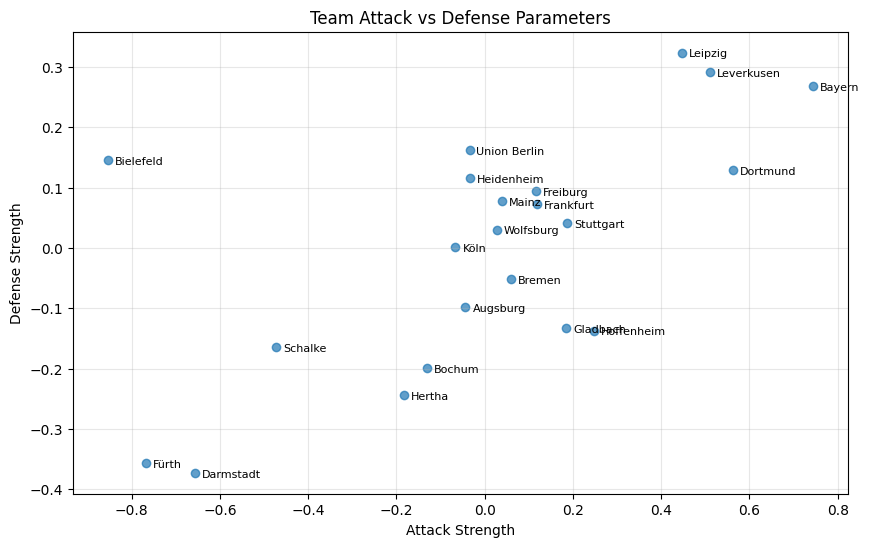

In [5]:
team_params = poisson_model.get_team_params()

# Visualize team attack vs defense
plt.figure(figsize=(10, 6))
plt.scatter(team_params["attack"], team_params["defense"], alpha=0.7)

# Add labels for some interesting teams
for i, row in team_params.iterrows():
    plt.annotate(
        row["team"],
        (row["attack"], row["defense"]),
        xytext=(5, -3),
        textcoords="offset points",
        fontsize=8,
    )

plt.xlabel("Attack Strength")
plt.ylabel("Defense Strength")
plt.title("Team Attack vs Defense Parameters")
plt.grid(True, alpha=0.3)
plt.show()

**Key insights:**
- Teams closer to the top-right are generally stronger overall
- Zero-sum constraints mean parameters are relative - a team with $\alpha_i = 0.2$ attacks $\exp(0.2) \approx 1.22$ times better than average

## Model Evaluation

We evaluate the Poisson model using time-series cross-validation and compare it against a baseline model.

In [6]:
poisson_cv_result = cross_validate_model(PoissonModel(max_goals=4), df_matches)
print(f"Poisson Model CV Results:")
poisson_cv_result.print_summary()

baseline_cv_result = cross_validate_model(BaselineModel(max_goals=4), df_matches)
print(f"\nBaseline Model CV Results:")
baseline_cv_result.print_summary()

Poisson Model CV Results:
Mean score: 455.3 ± 19.0
Individual scores: [458, 467, 443, 476, 434, 414, 457, 464, 423, 466, 477, 476, 460, 459]

Baseline Model CV Results:
Mean score: 409.6 ± 18.2
Individual scores: [406, 426, 382, 378, 404, 386, 414, 410, 430, 438, 408, 398, 426, 428]


Let's make predictions for 2024 and 2025 and save them to disk.

In [10]:
df_matches = pd.read_pickle("data/matches.pkl")
df_matches = df_matches[df_matches["league"] == "bl1"]

year = 2024
horizon = 6
df_train = df_matches[
    (df_matches["season"] < year) & (df_matches["season"] >= year - horizon)
]
df_test = df_matches[df_matches["season"] == year]
poisson_model = PoissonModel(max_goals=4)
poisson_model.fit(df_train)
poisson_test_guesses = poisson_model.predict(df_test)
df_predictions = df_test.copy()
df_predictions["home_goals_pred"] = poisson_test_guesses[:, 0]
df_predictions["away_goals_pred"] = poisson_test_guesses[:, 1]
df_predictions.to_pickle(f"data/predictions_poisson_{year}.pkl")

predictions = df_predictions[["home_goals_pred", "away_goals_pred"]].values
labels = df_predictions[["home_goals", "away_goals"]].values
kicktipp_scores = np.zeros(len(labels))
for i in range(len(predictions)):
    pred = (predictions[i, 0], predictions[i, 1])
    ground_truth = (labels[i, 0], labels[i, 1])
    kicktipp_scores[i] = kicktipp_scoring_rule(ground_truth, pred)
df_predictions["score"] = kicktipp_scores

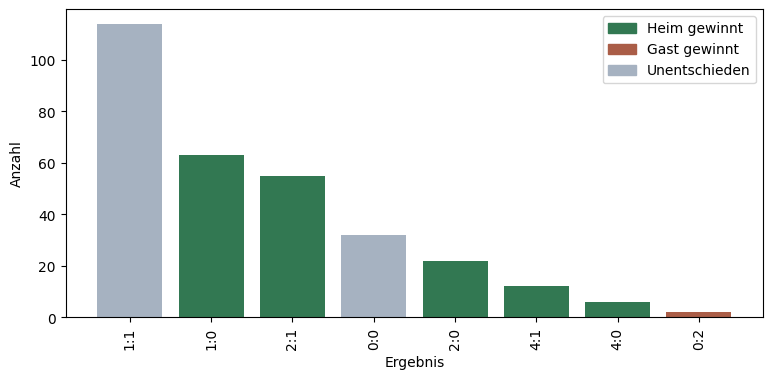

In [11]:
goals_encoded = [f"{int(r[0])}:{int(r[1])}" for r in predictions]
results, counts = np.unique(goals_encoded, return_counts=True)
sort = np.argsort(-counts)
counts = counts[sort]
results = results[sort]
tendency = [1] * len(results)
for i, res in enumerate(results):
    goals = res.split(":")
    if goals[0] > goals[1]:
        tendency[i] = 0
    elif goals[0] < goals[1]:
        tendency[i] = 2

y_test_colors = [
    [
        theme.MATCH_RESULT["home_wins"],
        theme.MATCH_RESULT["draw"],
        theme.MATCH_RESULT["away_wins"],
    ][r]
    for r in tendency
]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(results)), counts, color=y_test_colors)
ax.set_xlabel("Ergebnis")
ax.set_ylabel(f"Anzahl")
ax.set_xticks(range(len(results)), results, rotation=90)

orange_patch = mpatches.Patch(
    color=theme.MATCH_RESULT["away_wins"], label="Gast gewinnt"
)
green_patch = mpatches.Patch(
    color=theme.MATCH_RESULT["home_wins"], label="Heim gewinnt"
)
blue_patch = mpatches.Patch(color=theme.MATCH_RESULT["draw"], label="Unentschieden")
ax.legend(handles=[green_patch, orange_patch, blue_patch])

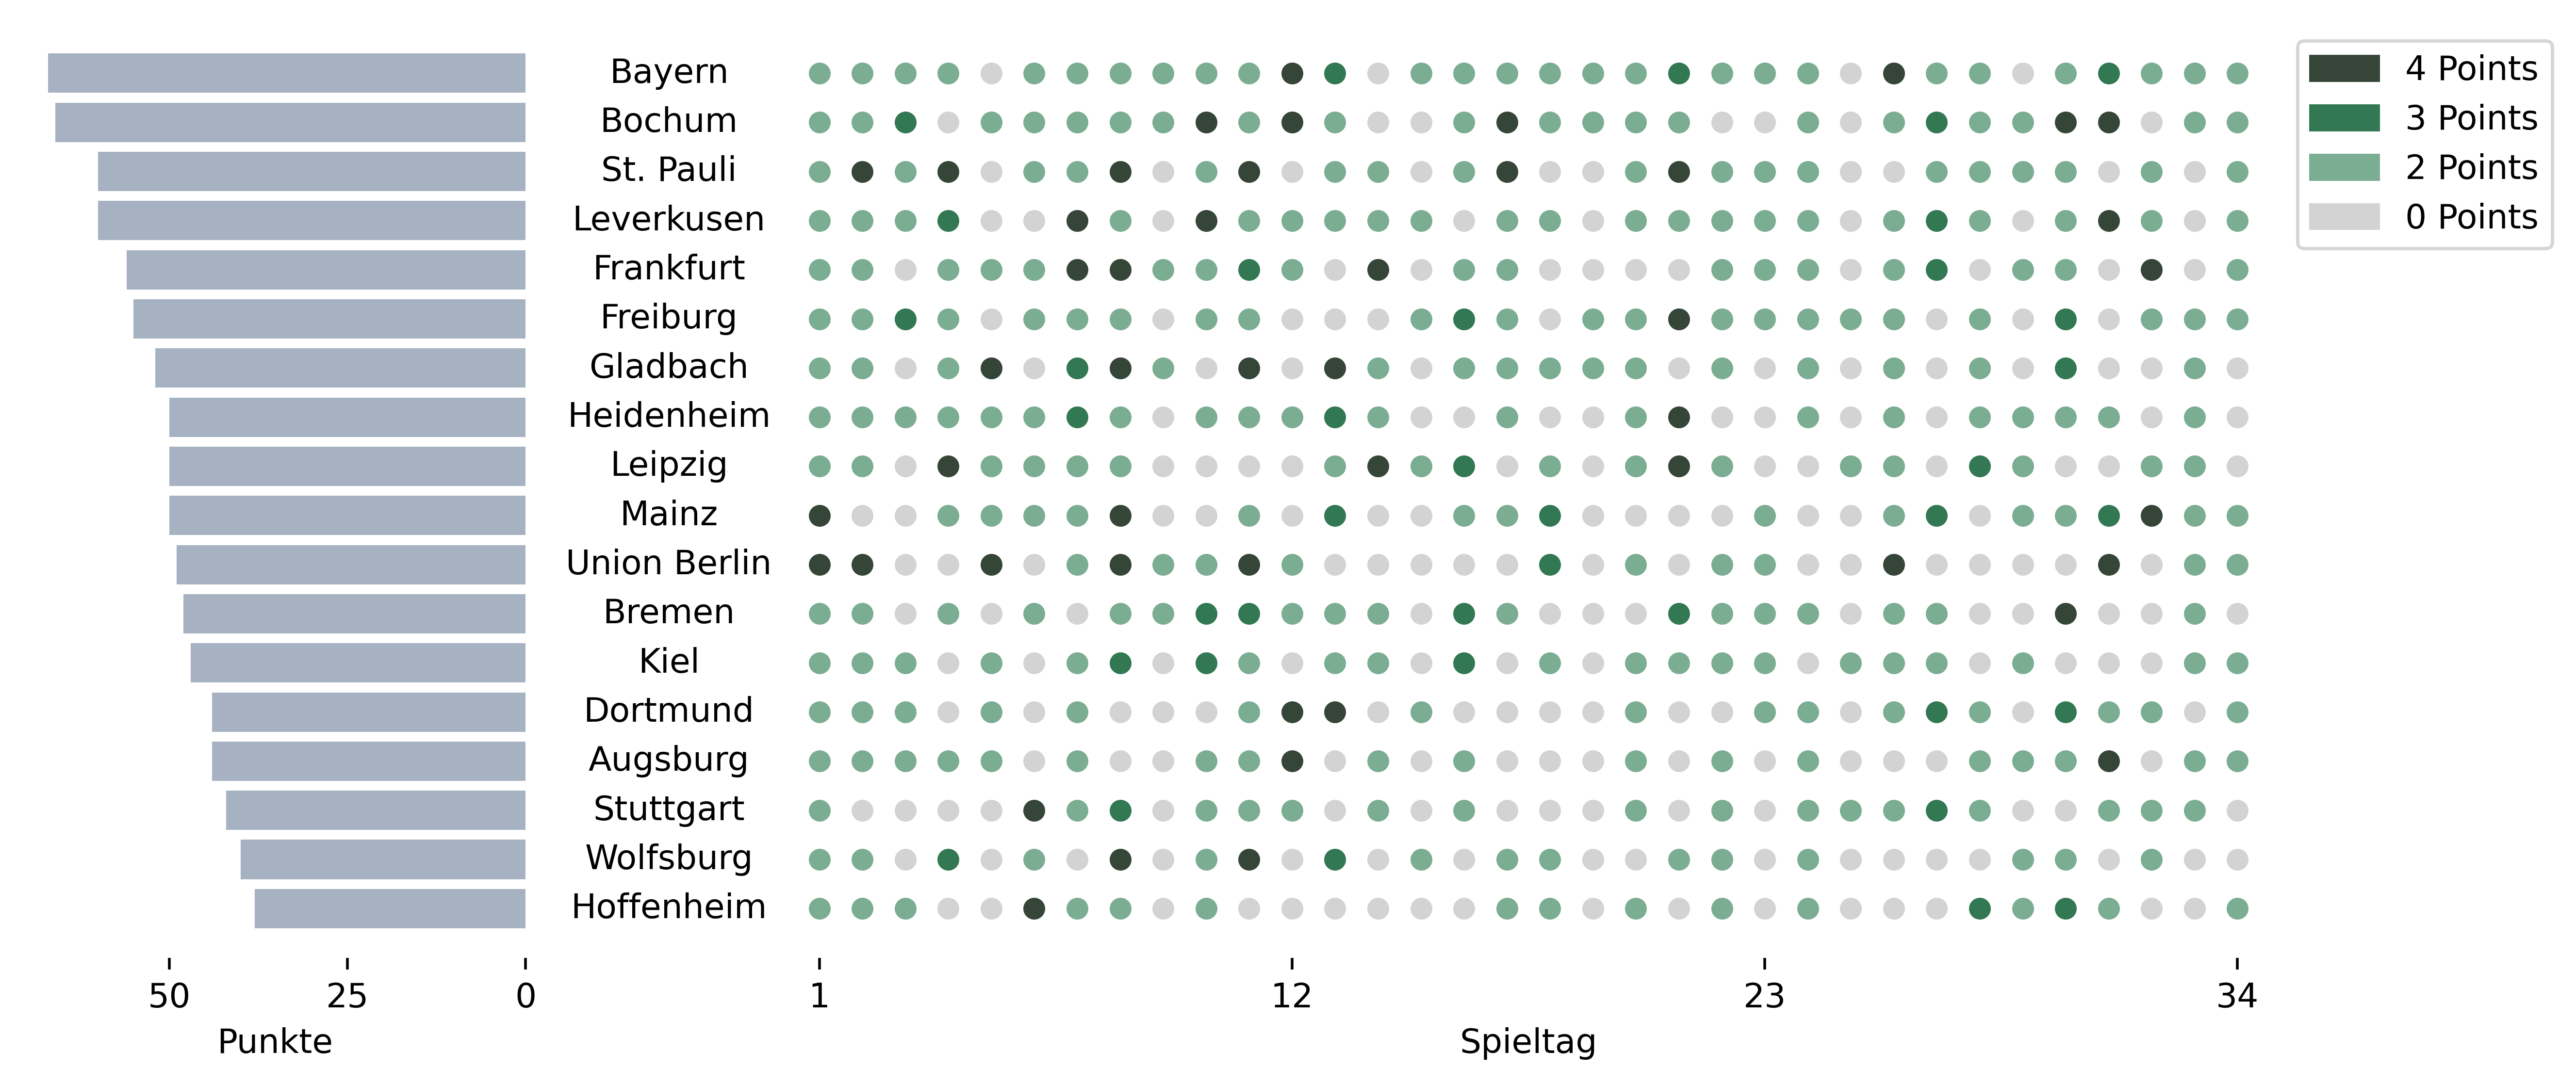

In [12]:
fig, axs = plt.subplots(
    ncols=2,
    figsize=(12, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [1, 3], "wspace": 0.25},
    dpi=500,
)

ax = axs[0]
team_host_scores = (
    df_predictions[["home", "score"]].groupby(["home"]).sum().sort_index()
)
team_guest_scores = (
    df_predictions[["away", "score"]].groupby(["away"]).sum().sort_index()
)
team_scores = team_host_scores["score"].values + team_guest_scores["score"].values
sort = np.argsort(team_scores)
team_scores = team_scores[sort].astype(int)
team_names = team_host_scores.index.values
team_names = team_names[sort]

color = [theme.GRAY] * len(team_names)
color = np.array(color)
# color[:3] = theme.MATCH_RESULT["guest_wins"]
# color[-3:] = theme.GRASS_D
ax.invert_xaxis()
rects = ax.barh(team_names, team_scores, color=color)
ax.set_frame_on(False)
# ax.bar_label(rects, team_scores, padding=5)
ax.set_xlabel("Punkte")
ax.set_xticks([0, 25, 50])


ax = axs[1]
ax.set_xlim(0, 34 + 1)
ax.set_ylim(-1, 18)
ax.set_xlabel("Spieltag")
ax.get_yaxis().set_ticks([])
ax.get_xaxis().set_ticks(range(1, 36, 11))
ax.set_frame_on(False)

for i, team in enumerate(team_names):
    ax.text(-2.5, i, team, horizontalalignment="center", verticalalignment="center")
    for matchday in range(1, 34 + 1):
        s = df_predictions.loc[
            (df_predictions["match_day"] == matchday)
            & ((df_predictions["home"] == team) | (df_predictions["away"] == team)),
            "score",
        ].values[0]
        if s == 4:
            color = theme.GRASS_D
        elif s == 3:
            color = theme.GRASS
        elif s == 2:
            color = theme.GRASS_B
        else:
            color = "lightgray"
        ax.scatter(matchday, i, s=30, color=color)

green_patch = mpatches.Patch(color=theme.GRASS_D, label="4 Points")
orange_patch = mpatches.Patch(color=theme.GRASS, label="3 Points")
blue_patch = mpatches.Patch(color=theme.GRASS_B, label="2 Points")
gray_patch = mpatches.Patch(color="lightgray", label="0 Points")
ax.legend(
    handles=[green_patch, orange_patch, blue_patch, gray_patch],
    loc="upper left",
    bbox_to_anchor=(1.0, 1.0),
)

In [14]:
df_matches = pd.read_pickle("data/matches.pkl")
df_matches = df_matches[df_matches["league"] == "bl1"]

year = 2025
df_train = df_matches[
    (df_matches["season"] < year) & (df_matches["season"] >= year - horizon)
]
df_test = df_matches[df_matches["season"] == year]
poisson_model = PoissonModel(max_goals=4)
poisson_model.fit(df_train)
poisson_test_guesses = poisson_model.predict(df_test)
df_predictions = df_test.copy()
df_predictions["home_goals_pred"] = poisson_test_guesses[:, 0]
df_predictions["away_goals_pred"] = poisson_test_guesses[:, 1]
df_predictions.to_pickle(f"data/predictions_poisson_{year}.pkl")